# Sol-Gel Synthesis Dataset — Tutorial

This notebook provides a hands-on introduction to the text-mined inorganic sol-gel synthesis dataset.

Each record in the dataset is a single synthesis protocol extracted from a scientific paper and contains
three top-level sections:

| Key | Contents |
|---|---|
| `protocol` | DOI, target material (parsed), metal precursors (parsed), reagents (with PubChem data) |
| `operations` | Ordered list of synthesis steps with parsed time, temperature, pH, ratios, atmosphere |
| `phase_purity` | Phase purity classification, impurity phases (parsed), characterization methods |

In [1]:
import json
from collections import Counter

DATASET_FILE = "sol_gel_dataset.jsonl"

records = []
with open(DATASET_FILE, "r", encoding="utf-8") as f:
    for line in f:
        if line.strip():
            records.append(json.loads(line))

classifications = [r["phase_purity"]["classification"] for r in records]
unique_dois = len({r["protocol"]["doi"] for r in records})
cls_counts = Counter(classifications)

print(f"Dataset file:        {DATASET_FILE}")
print(f"Total records:       {len(records):,}")
print(f"Unique DOIs:         {unique_dois:,}")
print()
print("Phase purity breakdown:")
for label, count in cls_counts.most_common():
    print(f"  {label:<20} {count:>7,}  ({count/len(records)*100:.1f}%)")
print()
print("Top-level keys in each record:", list(records[0].keys()))
print("protocol keys:       ", list(records[0]["protocol"].keys()))
print("phase_purity keys:   ", list(records[0]["phase_purity"].keys()))
print("Sample operation keys:", list(records[0]["operations"][0].keys()) if records[0]["operations"] else "none")

Dataset file:        sol_gel_dataset.jsonl
Total records:       148,024
Unique DOIs:         53,422

Phase purity breakdown:
  Pure                 112,579  (76.1%)
  Impure                27,967  (18.9%)
  Insufficient info      7,478  (5.1%)

Top-level keys in each record: ['protocol', 'operations', 'phase_purity']
protocol keys:        ['doi', 'target', 'metal_precursors', 'reagents']
phase_purity keys:    ['impurity_phase', 'phase_purity_details', 'classification', 'characterization_methods']
Sample operation keys: ['operation_type', 'operation_details', 'time', 'temperature', 'pH', 'ratios', 'atmosphere']


In [ ]:
# Pretty-print one full record so you can see the complete data structure.
# This is the first record in the dataset.
print(json.dumps(records[0], indent=2, ensure_ascii=False))

{
  "protocol": {
    "doi": "10.1016/j.ceramint.2013.07.044",
    "target": {
      "material_string": "SrTiO3",
      "material_form": "powder",
      "material_formula": "SrTiO3",
      "composition": [
        {
          "formula": "SrTiO3",
          "amount": "1",
          "elements": {
            "Sr": "1",
            "Ti": "1",
            "O": "3"
          },
          "species": {
            "Sr": "1",
            "TiO3": "1"
          }
        }
      ],
      "additives": [],
      "is_mixture": false,
      "phase": "",
      "oxygen_deficiency": "no",
      "oxidation_states": {
        "Sr": [
          2
        ],
        "Ti": [
          4
        ],
        "O": [
          -2
        ]
      }
    },
    "metal_precursors": [
      {
        "material_string": "Sr(NO3)2",
        "material_form": "",
        "material_formula": "Sr(NO3)2",
        "composition": [
          {
            "formula": "Sr(NO3)2",
            "amount": "1",
            "elements

## Dataset Coverage — Elemental Periodic Table Heatmap

Each element tile is split diagonally:
- **Upper-left triangle (red scale):** log₁₀ of the total number of data records containing that element
- **Lower-right triangle (blue scale):** average fraction of phase-pure outcomes across ternary compounds
  containing that element (only compounds with ≥10 classified records and elements with ≥3 such compounds)

**Methodological notes:**
- Element membership is determined by re-parsing `material_formula` with pymatgen. Formulas with
  variable stoichiometry (e.g. `La1-xSrxMnO3`) or composite notation (e.g. `TiO2-SiO2`) fail parsing
  and are intentionally excluded. 
- The purity threshold requires ≥10 **classifiable** (Pure or Impure) records per compound,
  excluding records classified as 'Insufficient info'.

In [3]:
import numpy as np
from collections import Counter, defaultdict
from pymatgen.core import Composition, Element
from pymatviz import ptable_heatmap_splits
import plotly.graph_objects as go

# --- Step 1: Accumulate per-formula statistics ---
# We track pure, impure, and total (including Insufficient Info) counts separately.
# total_records is used for the upper-triangle record count;
# pure+impure is used for the purity fraction threshold and calculation.
formula_stats = defaultdict(lambda: {"pure": 0, "impure": 0, "total_records": 0})

for entry in records:
    target = entry.get("protocol", {}).get("target", {})
    formula = target.get("material_formula")
    if not formula or not isinstance(formula, str):
        continue

    cls = entry.get("phase_purity", {}).get("classification")
    if cls == "Pure":
        formula_stats[formula]["pure"] += 1
    elif cls == "Impure":
        formula_stats[formula]["impure"] += 1
    # Always increment total (includes Insufficient Info records)
    formula_stats[formula]["total_records"] += 1

# --- Step 2: Map formulas to elements using pymatgen ---
# Pymatgen re-parses material_formula rather than using the stored composition field.
# This intentionally excludes ambiguous formulas (variable stoichiometry, composite notation)
# that don't represent a single well-defined compound.
element_counts = Counter()       # total records per element (for upper triangle)
element_purity_list = defaultdict(list)  # per-element list of per-compound purity fractions

MIN_RECORDS_PER_COMPOUND = 10   # minimum pure+impure records for a compound to contribute
MIN_N = 3                        # minimum qualifying compounds for an element to show a value

for formula, stats in formula_stats.items():
    try:
        comp = Composition(formula)
        symbols = {el.symbol for el in comp.elements}
        n_elements = len(symbols)

        # Upper triangle: total records regardless of element count or purity
        for sym in symbols:
            element_counts[sym] += stats["total_records"]

        # Lower triangle: ternaries only, threshold on pure+impure (not total)
        # This ensures Insufficient Info records cannot inflate a compound into qualifying.
        relevant_count = stats["pure"] + stats["impure"]
        if n_elements == 3 and relevant_count >= MIN_RECORDS_PER_COMPOUND:
            purity_fraction = stats["pure"] / relevant_count
            for sym in symbols:
                element_purity_list[sym].append(purity_fraction)

    except Exception:
        # pymatgen cannot parse this formula (e.g. La1-xSrxMnO3) — skip it
        continue

# --- Step 3: Average purity per element ---
avg_purity = {
    sym: np.mean(vals)
    for sym, vals in element_purity_list.items()
    if len(vals) >= MIN_N
}

# --- Step 4: Build the combined data dict for all 118 elements ---
INSUFF_COLOR = "#dddddd"          # grey: in dataset but insufficient purity data
NOT_IN_DATASET_COLOR = "#f7f7f7"  # near-white: element not in dataset at all

all_pt_symbols = [el.symbol for el in Element if el.Z <= 118]

combined_data = {}
for sym in all_pt_symbols:
    if sym in element_counts:
        combined_data[sym] = [
            np.log10(element_counts[sym]),
            avg_purity.get(sym, np.nan),
        ]
    else:
        combined_data[sym] = [np.nan, np.nan]

# --- Step 5: Plot ---
fig = ptable_heatmap_splits(
    combined_data,
    orientation="diagonal",
    colorscale=["Reds", "YlGnBu"],
    colorbar=[
        {
            "title": "Total Records (10ˣ Scale)",
            "x": 1.0,
            "tickvals": [1, 2, 3, 4, 5],
            "ticktext": ["1", "2", "3", "4", "5"],
            "tickformat": "",
        },
        {
            "title": "Average Fraction of Phase Pure Records (Ternaries Only)",
            "x": 1.12,
        },
    ],
    on_empty="hide",
    nan_color=INSUFF_COLOR,
    hover_fmt=".3g",
    split_value_fmt=".2f",
    font_size=12,
    symbol_kwargs=dict(font=dict(size=16)),
    hover_data={
        sym: (
            f"Count: {element_counts[sym]:,}"
            if sym in element_counts
            else "Not in dataset"
        )
        for sym in all_pt_symbols
    },
)

# Remap annotations to recolor "not in dataset" tiles correctly
sym_to_axis = {}
all_element_symbols = {el.symbol for el in Element}
for ann in fig.layout.annotations:
    txt = (ann.text or "").replace("<b>", "").replace("</b>", "").strip()
    if ann.xref and ann.xref.startswith("x") and txt in all_element_symbols:
        sym_to_axis[txt] = ann.xref.replace("x", "") or "1"

not_in_dataset = {sym for sym in all_pt_symbols if sym not in element_counts}
for sym in not_in_dataset:
    axis_str = sym_to_axis.get(sym)
    if axis_str is None:
        continue
    for trace in fig.data:
        axis = (trace.xaxis or "x").replace("x", "") or "1"
        if axis == axis_str and trace.fill == "toself":
            trace.fillcolor = NOT_IN_DATASET_COLOR
            if trace.line:
                trace.line.color = NOT_IN_DATASET_COLOR

# Fix purity colorbar range to 0–1
cb_traces = [t for t in fig.data if t.marker and t.marker.colorscale is not None]
if len(cb_traces) >= 2:
    purity_cb_trace = cb_traces[1]
    purity_cb_trace.marker.cmin = 0.0
    purity_cb_trace.marker.cmax = 1.0
    purity_cb_trace.marker.colorbar.tickvals   = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
    purity_cb_trace.marker.colorbar.ticktext   = ["0.00", "0.20", "0.40", "0.60", "0.80", "1.00"]
    purity_cb_trace.marker.colorbar.tickformat = ""

# Add legend entries for the two special tile colors
fig.add_trace(go.Scatter(
    x=[None], y=[None], mode="markers",
    marker=dict(size=14, color=INSUFF_COLOR, symbol="square", line=dict(color="gray", width=1)),
    name=f"In dataset — insufficient purity data<br>"
         f"(< {MIN_N} ternary compounds with ≥{MIN_RECORDS_PER_COMPOUND} records)",
    showlegend=True,
))
fig.add_trace(go.Scatter(
    x=[None], y=[None], mode="markers",
    marker=dict(size=14, color=NOT_IN_DATASET_COLOR, symbol="square", line=dict(color="gray", width=1)),
    name="Not present in dataset",
    showlegend=True,
))

fig.update_layout(
    title=dict(
        text=(
            "Elemental Trends — Lower-Left: Total Records (10ˣ Scale) | "
            "Upper-Right: Avg Phase Purity "
            f"(ternaries only, ≥{MIN_RECORDS_PER_COMPOUND} records/compound, "
            f"≥{MIN_N} compounds/element)"
        ),
        font_size=15,
    ),
    paper_bgcolor="white",
    plot_bgcolor="white",
    legend=dict(
        x=0.13, y=0.97, xanchor="left", yanchor="top",
        orientation="h", bgcolor="white", bordercolor="gray", borderwidth=1,
        font=dict(size=12),
    ),
    width=1500,
    height=700,
)

fig.show()

## Top Ternary Compounds

The function below summarizes the most-synthesized ternary compounds ranked by total record count,
with their phase-pure fraction, top precursors, reagents, and most common impurity phases.

**How to use:** call `ternary_report(records)` to see the top-5 compounds by record count, pass
`top_n=20` to extend the ranking, or `formula="BaTiO3"` to look up a specific material.

In [4]:
import re
from collections import Counter


def _is_ternary(entry):
    """Return True if the target has exactly 3 distinct elements.
    Reads from the stored composition field (set by text2chem during post-processing)."""
    target = entry.get("protocol", {}).get("target", {})
    symbols = {
        el
        for comp in (target.get("composition") or [])
        for el in (comp.get("elements") or {})
    }
    return len(symbols) == 3


def _normalize_precursor(formula):
    """Strip hydrate suffixes and normalize nitrate variants to a canonical form.
    e.g. Fe(NO3)3·9H2O -> Fe(NO3)3"""
    if not formula:
        return formula
    m = re.match(r'^(.+?\(NO3\)\d*)', formula)
    if m:
        return m.group(1)
    return re.sub(r'[·⋅•\*\.]?\s*\d*\s*H2O.*$', '', formula).strip() or formula


def ternary_report(dataset, top_n=5, formula=None):
    """
    Print a summary for the top ternary compounds by record count.

    Parameters
    ----------
    dataset : list
        The full list of records (e.g. `records`).
    top_n : int
        How many compounds to show (ranked by total record count). Default 5.
    formula : str or None
        If given, show only this specific formula instead of the top-N ranking.
        Example: formula="BaTiO3"
    """
    ternary = [d for d in dataset if _is_ternary(d)]

    if formula:
        subset_map = {formula: [d for d in ternary
                                 if d["protocol"]["target"].get("material_formula") == formula]}
    else:
        formula_counts = Counter(
            d["protocol"]["target"]["material_formula"] for d in ternary
        )
        subset_map = {
            f: [d for d in ternary if d["protocol"]["target"]["material_formula"] == f]
            for f, _ in formula_counts.most_common(top_n)
        }

    for f, subset in subset_map.items():
        if not subset:
            print(f"No ternary records found for {f!r}.")
            continue

        n_pure   = sum(1 for d in subset if d.get("phase_purity", {}).get("classification") == "Pure")
        n_impure = sum(1 for d in subset if d.get("phase_purity", {}).get("classification") == "Impure")
        denom    = n_pure + n_impure
        frac_str = f"{n_pure/denom:.1%}" if denom else "N/A"

        # Top precursors (hydrate/nitrate variants collapsed)
        prec_counter = Counter()
        for d in subset:
            for mp in d.get("protocol", {}).get("metal_precursors", []):
                f_prec = _normalize_precursor(mp.get("material_formula"))
                if f_prec:
                    prec_counter[f_prec] += 1

        # Top reagents (only those with a resolved PubChem CID)
        reag_counter = Counter()
        for d in subset:
            for r in d.get("protocol", {}).get("reagents", []):
                if r.get("pubchem_CID") and r.get("reagent_string"):
                    reag_counter[(r["pubchem_CID"], r["reagent_string"].strip())] += 1

        # Top impurity phases
        imp_counter = Counter()
        for d in subset:
            for phase in d.get("phase_purity", {}).get("impurity_phase", []):
                label = phase.get("material_formula") if isinstance(phase, dict) else phase
                if label:
                    imp_counter[label] += 1

        print(f"\n{'='*62}")
        print(f"  {f}  |  {len(subset):,} total records  |  Purity: {frac_str} ({n_pure}/{denom})")
        print(f"{'='*62}")

        print("  Top precursors:")
        for p, cnt in prec_counter.most_common(6):
            print(f"    {cnt:>4}  {p}")

        print("  Top reagents:")
        for (cid, name), cnt in reag_counter.most_common(6):
            print(f"    {cnt:>4}  {name} (CID: {cid})")

        print("  Top impurity phases:")
        if imp_counter:
            for p, cnt in imp_counter.most_common(6):
                print(f"    {cnt:>4}  {p}")
        else:
            print("    (none recorded)")


# Top 5 ternary compounds by total record count
ternary_report(records, top_n=5)

# Uncomment to query a specific compound:
# ternary_report(records, formula="SrTiO3")


  BiFeO3  |  1,220 total records  |  Purity: 66.1% (789/1194)
  Top precursors:
    1122  Fe(NO3)3
    1086  Bi(NO3)3
      35  Bi2O3
      22  Bi(NO3)2
      21  Bi(CH3COO)3
      17  Fe(CH3COCHCOCH3)3
  Top reagents:
     317  ethylene glycol (CID: 174)
     285  2-methoxyethanol (CID: 8019)
     270  nitric acid (CID: 944)
     267  citric acid (CID: 311)
     191  acetic acid (CID: 176)
     167  tartaric acid (CID: 444305)
  Top impurity phases:
     207  Bi2Fe4O9
      82  Bi25FeO40
      69  Bi2O3
      32  Fe2O3
      29  Bi25FeO39
      24  Bi24Fe2O39

  CoFe2O4  |  1,081 total records  |  Purity: 86.4% (911/1054)
  Top precursors:
     932  Fe(NO3)3
     819  Co(NO3)2
      88  Co(NO3)3
      35  Fe(NO3)2
      32  Co(CH3CO2)2
      30  FeCl3
  Top reagents:
     497  citric acid (CID: 311)
     241  distilled water (CID: 962)
     209  deionized water (CID: 962)
     136  water (CID: 962)
     133  ammonia (CID: 222)
     125  ethanol (CID: 702)
  Top impurity phases:
     

## BiFeO₃ Thin Film Example

BiFeO₃ (BFO) thin films are one of the most studied multiferroic systems in the sol-gel literature.
The cells below explore how reagent choice, processing temperature, and impurity formation relate
to phase purity outcomes across BFO thin-film synthesis records in the dataset.

In [8]:
# =============================================================================
# Phase purity by reagent / solvent route
#
# Grouping is based on the exact set of PubChem CIDs assigned to each record:
#   2-methoxyethanol (2ME) = CID 8019
#   citric acid (CA)       = CID 311
#
# A record is assigned to a group only if its resolved CID set matches exactly,
# so records where PubChem lookup failed fall into 'remaining routes'.
# =============================================================================

TARGET_FORMULA = "BiFeO3"
TARGET_FORM    = "thin film"

bfo = [
    d for d in records
    if d.get("protocol", {}).get("target", {}).get("material_formula") == TARGET_FORMULA
    and d.get("protocol", {}).get("target", {}).get("material_form", "").lower() == TARGET_FORM
]

print(f"Total BiFeO3 thin-film records: {len(bfo)}")

CID_2ME = 8019   # 2-methoxyethanol
CID_CA  = 311    # citric acid


def reagent_route_stats(dataset, cid_sets_labels):
    """
    Compute phase purity statistics for groups of records defined by their
    exact resolved PubChem CID set.

    Parameters
    ----------
    dataset : list
        Records to analyse (should already be filtered to a target formula/form).
    cid_sets_labels : list of (frozenset, str)
        Each tuple is (exact CID set, group label). Records not matching any
        defined set fall into a 'remaining routes' group automatically.
    """
    groups = {label: [] for _, label in cid_sets_labels}
    groups["remaining routes"] = []

    for d in dataset:
        cls = d.get("phase_purity", {}).get("classification")
        if cls not in ("Pure", "Impure"):
            continue

        cids = frozenset(
            r.get("pubchem_CID")
            for r in d.get("protocol", {}).get("reagents", [])
            if r.get("pubchem_CID") is not None
        )

        matched = False
        for cid_set, label in cid_sets_labels:
            if cids == cid_set:
                groups[label].append(d)
                matched = True
                break
        if not matched:
            groups["remaining routes"].append(d)

    print(f"{'Route':<22} {'Pure/Total':>12}   {'Purity':>7}")
    print("-" * 46)
    for label, grp in groups.items():
        if not grp:
            continue
        n_pure  = sum(1 for d in grp if d["phase_purity"]["classification"] == "Pure")
        n_total = len(grp)
        print(f"  {label:<20} {n_pure}/{n_total:>6}      {n_pure/n_total:.0%}")


reagent_route_stats(
    bfo,
    cid_sets_labels=[
        (frozenset({CID_2ME}),          "2ME alone"),
        (frozenset({CID_2ME, CID_CA}),  "2ME + citric acid"),
    ]
)

Total BiFeO3 thin-film records: 372
Route                    Pure/Total    Purity
----------------------------------------------
  2ME alone            24/    27      89%
  2ME + citric acid    12/    12      100%
  remaining routes     252/   328      77%


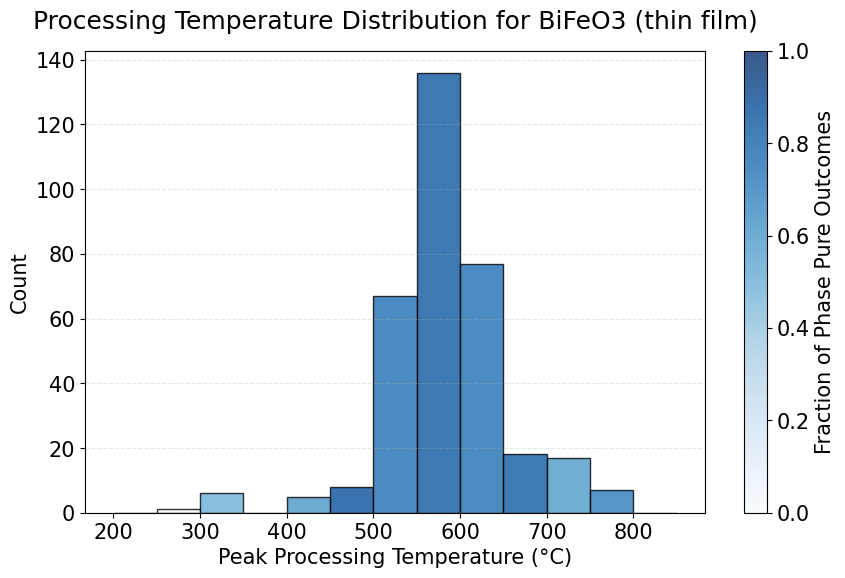

Temperature range: 500–650°C
  Records: 238/296 phase-pure (80.4%)
Temperature range: 700–2000°C
  Records: 18/27 phase-pure (66.7%)
Temperature range: 250–450°C
  Records: 13/20 phase-pure (65.0%)
  Unique DOIs (13):
    https://doi.org/10.1016/j.apsusc.2012.04.166
    https://doi.org/10.1016/j.ceramint.2018.08.069
    https://doi.org/10.1016/j.jmmm.2006.02.219
    https://doi.org/10.1016/j.jmmm.2018.11.089
    https://doi.org/10.1016/j.jmrt.2021.01.078
    https://doi.org/10.1016/j.physb.2010.10.058
    https://doi.org/10.1016/j.scitotenv.2020.138640
    https://doi.org/10.1016/j.tsf.2009.10.138
    https://doi.org/10.1016/j.tsf.2019.137687
    https://doi.org/10.1039/C4TC00960F
    https://doi.org/10.1039/C9NJ00214F
    https://doi.org/10.1063/1.2335399
    https://doi.org/10.1063/1.5134972


In [10]:
# =============================================================================
# Phase purity vs. peak processing temperature
#
# Each record's peak temperature is the maximum temperature.max_value across
# all its synthesis operations. Bar colour encodes the fraction of phase-pure
# outcomes in that 50 °C bin (darker blue = higher purity).
# =============================================================================

import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({"font.size": 15})

# Build parallel arrays: peak temperature and outcome (1=Pure, 0=Impure).
# Only include records that have both a temperature and a Pure/Impure classification.
temps, outcomes = [], []
for entry in bfo:
    ops_temps = [
        op.get("temperature", {}).get("max_value")
        for op in entry.get("operations", [])
        if op.get("temperature", {}).get("max_value") not in (None, "")
    ]
    cls = entry.get("phase_purity", {}).get("classification")
    if ops_temps and cls in ("Pure", "Impure"):
        temps.append(max(ops_temps))
        outcomes.append(1 if cls == "Pure" else 0)

temps_arr    = np.array(temps)
outcomes_arr = np.array(outcomes)

# Bin into 50 °C windows and compute per-bin purity fraction
bin_edges = np.arange(200, 900, 50)
hist, _    = np.histogram(temps_arr, bins=bin_edges)
bin_purity = []
for i in range(len(bin_edges) - 1):
    mask = (temps_arr >= bin_edges[i]) & (temps_arr < bin_edges[i + 1])
    bin_purity.append(np.mean(outcomes_arr[mask]) if mask.any() else 0)

fig, ax = plt.subplots(figsize=(10, 6))
cmap = plt.cm.Blues
norm = plt.Normalize(0, 1)
bin_width = bin_edges[1] - bin_edges[0]

for i in range(len(hist)):
    ax.bar(
        bin_edges[i], hist[i], width=bin_width, align="edge",
        color=cmap(norm(bin_purity[i])), edgecolor="black", alpha=0.8,
    )

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
plt.colorbar(sm, alpha=0.8, ax=ax, label="Fraction of Phase Pure Outcomes")
ax.set_xlabel("Peak Processing Temperature (°C)")
ax.set_ylabel("Count")
ax.set_title(f"Processing Temperature Distribution for {TARGET_FORMULA} ({TARGET_FORM})", pad=16)
ax.grid(axis="y", linestyle="--", alpha=0.3)
plt.show()


# --- Query function: purity fraction and DOIs for any temperature window ---
def purity_by_temp_range(temps_arr, outcomes_arr, all_records, temp_min, temp_max, show_dois=True):
    """
    Report phase purity statistics and source DOIs for records whose peak
    processing temperature falls within [temp_min, temp_max] (both inclusive).

    Parameters
    ----------
    temps_arr    : np.ndarray  — peak temperatures (built above)
    outcomes_arr : np.ndarray  — outcomes aligned with temps_arr
    all_records  : list        — bfo_classified list, aligned with the arrays
    temp_min     : float       — lower bound in °C (inclusive)
    temp_max     : float       — upper bound in °C (inclusive)
    show_dois    : bool        — if True, print all DOIs in the range

    Note: this range query is inclusive on both ends, matching how the
    manuscript reports ranges (e.g. 500–650 °C -> 238/296). The histogram
    above, being a partition, uses left-inclusive bins [lo, hi); a record
    at exactly 650 °C is counted here in [500, 650] but is drawn in the
    650–700 °C bar. To reproduce a single plot bar, query [lo, hi-eps].
    """
    mask = (temps_arr >= temp_min) & (temps_arr <= temp_max)
    if not mask.any():
        print(f"No records found between {temp_min}°C and {temp_max}°C.")
        return

    n_pure  = int(np.sum(outcomes_arr[mask]))
    n_total = int(np.sum(mask))
    print(f"Temperature range: {temp_min}–{temp_max}°C")
    print(f"  Records: {n_pure}/{n_total} phase-pure ({n_pure/n_total:.1%})")

    if show_dois:
        record_indices = [
            i for i, entry in enumerate(all_records)
            if (
                any(
                    op.get("temperature", {}).get("max_value") not in (None, "")
                    for op in entry.get("operations", [])
                )
                and entry.get("phase_purity", {}).get("classification") in ("Pure", "Impure")
            )
        ]
        matched_indices = [record_indices[j] for j in np.where(mask)[0]]
        dois = sorted({all_records[i]["protocol"]["doi"] for i in matched_indices})
        print(f"  Unique DOIs ({len(dois)}):")
        for doi in dois:
            print(f"    https://doi.org/{doi}")


# The bfo_classified list must stay aligned with temps_arr / outcomes_arr
bfo_classified = [
    entry for entry in bfo
    if any(
        op.get("temperature", {}).get("max_value") not in (None, "")
        for op in entry.get("operations", [])
    )
    and entry.get("phase_purity", {}).get("classification") in ("Pure", "Impure")
]

# Example queries — uncomment to explore specific temperature windows
purity_by_temp_range(temps_arr, outcomes_arr, bfo_classified, 500, 650, show_dois=False)
purity_by_temp_range(temps_arr, outcomes_arr, bfo_classified, 700, 2000, show_dois=False)
purity_by_temp_range(temps_arr, outcomes_arr, bfo_classified, 250, 450, show_dois=True)

Most common BiFeO3 thin-film impurity phases:
    30   Bi2Fe4O9
    20   Bi2O3
    13   Fe2O3
    10   unspecified
     4   SiO2
     3   Bi25FeO40
     2   Bi36Fe42O57
     2   Bi2Fe4O7


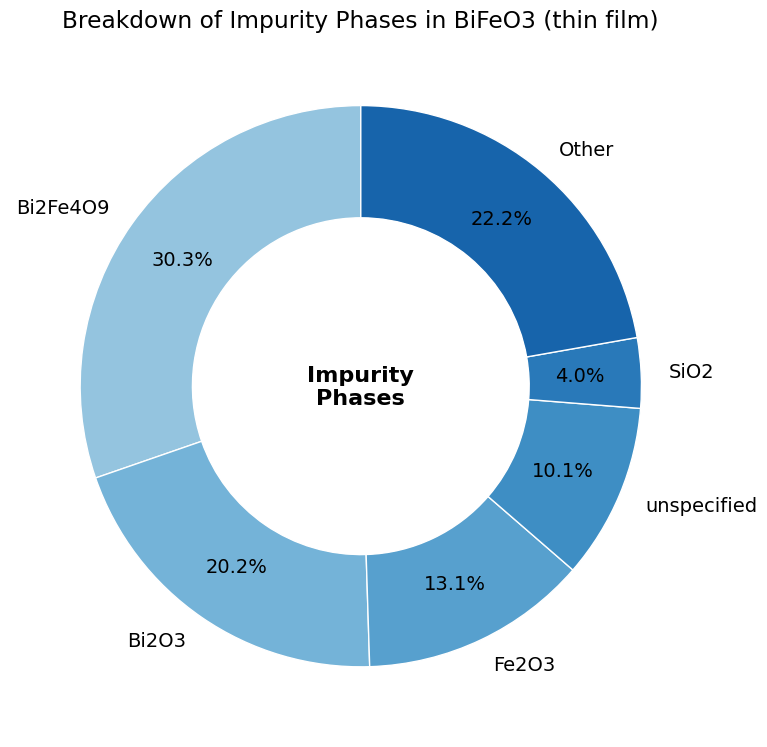

In [7]:
# =============================================================================
# Most common impurity phases in BiFeO3 thin films
#
# Counts each impurity phase recorded across all Impure BFO thin-film records.
# =============================================================================

import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

plt.rcParams.update({"font.size": 14})

impurity_counts = Counter()
for entry in bfo:
    if entry.get("phase_purity", {}).get("classification") != "Impure":
        continue
    for imp in entry.get("phase_purity", {}).get("impurity_phase", []):
        name = imp.get("material_formula") or imp.get("material_string") if isinstance(imp, dict) else imp
        if name:
            impurity_counts[name] += 1

print("Most common BiFeO3 thin-film impurity phases:")
for phase, cnt in impurity_counts.most_common(8):
    print(f"  {cnt:>4}   {phase}")

# --- Donut chart ---
TOP_N = 5
ordered    = impurity_counts.most_common()
top_labels = [k for k, _ in ordered[:TOP_N]]
top_sizes  = [v for _, v in ordered[:TOP_N]]
other_size = sum(v for _, v in ordered[TOP_N:])
if other_size:
    top_labels.append("Other")
    top_sizes.append(other_size)

fig, ax = plt.subplots(figsize=(8, 8))
colors = plt.cm.Blues(np.linspace(0.4, 0.8, len(top_labels)))

ax.pie(
    top_sizes, labels=top_labels, startangle=90,
    colors=colors, wedgeprops={"width": 0.4, "edgecolor": "w"},
    autopct=lambda p: f"{p:.1f}%" if p > 3 else "",
    pctdistance=0.78,
)
fig.gca().add_artist(plt.Circle((0, 0), 0.60, fc="white"))
ax.text(0, 0, "Impurity\nPhases", ha="center", va="center", fontsize=16, weight="bold")
ax.set_title(f"Breakdown of Impurity Phases in {TARGET_FORMULA} ({TARGET_FORM})")
plt.tight_layout()
plt.show()